# YOLO26x Beyond `predict()`: A Production Video Pipeline on AMD Radeon

**Speaker:** Zihao Mu, Member of Technical Staff, Product Application Engineering, AMD

Start with the Ultralytics API you already know, export YOLO26x to ONNX, then keep the complete no-VLM vision pass on the Radeon GPU:

```text
YOLO26x checkpoint -> ONNX -> Ultralytics/ORT MIGraphX -> OpenCV GPU NMS
                                                               |
rocDecode -> OpenCV HIP preprocess -> GPU I/O Binding -> compact detections
                                                               |
                                     bounded queue + dedicated HIP stream
                                                               |
                    DRM PRIME VAAPI surface: RGB -> NV12 + GPU overlay -> H.264
```

The workshop uses `YOLO.predict()` as the correctness baseline. In the continuous loop, Ultralytics still owns ONNX inference, OpenCV owns preprocessing and GPU NMS, and a small native bridge owns GPU overlay plus direct VA-API surface submission.

## 1. Prepare the official YOLO26x assets and validate Radeon

In [1]:
import importlib
import json
import os
import sys
from pathlib import Path


def find_package_root() -> Path:
    origins = [Path.cwd(), *(Path(value) for value in sys.path if value)]
    for origin in origins:
        for candidate in (origin, *origin.parents):
            if (
                (candidate / "scripts/notebook_env.py").is_file()
                and (candidate / "src").is_dir()
                and (candidate / "data").is_dir()
            ):
                return candidate.resolve()
    raise FileNotFoundError("Run this notebook from the ultralytics_yolo26 folder")


ROOT = find_package_root()
os.environ["ULTRALYTICS_YOLO26_ROOT"] = str(ROOT)
os.environ["ULTRALYTICS_YOLO26_MODEL_DIR"] = str(ROOT / "models")
os.environ["ULTRALYTICS_YOLO26_OUTPUT_DIR"] = str(ROOT / "output")
os.environ.setdefault(
    "ULTRALYTICS_MIGRAPHX_CACHE_ROOT", str(ROOT / "models/ort-migraphx-cache")
)
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
for value in (str(ROOT), str(ROOT / "src")):
    if value not in sys.path:
        sys.path.insert(0, value)

from scripts import notebook_env as env
env = importlib.reload(env)
from scripts.model_setup import ensure_models, model_status
from scripts.notebook_helpers import frame_at, show_bgr, show_bgr_grid, video_info
from scripts.validate_runtime import validate

models = ensure_models(env.MODELS, progress=True)
runtime = validate(require_models=True, require_vlm=False)
print(json.dumps(runtime, indent=2))
models

[models] yolo26x.pt: ready
[models] yolo26x.onnx: ready
[models] MIGraphX cache: /workspace/models/ort-migraphx-cache (created by the Ultralytics ONNX backend on first GPU inference)
[models] Qwen3-VL-8B-Instruct-Q8_0.gguf: ready
[models] mmproj-F16.gguf: ready


{
  "root": "/workspace",
  "src": "/workspace/src",
  "data": "/workspace/data",
  "models": "/workspace/models",
  "output": "/workspace/output",
  "opencv_install": "/opt/opencv5",
  "llamacpp": "http://ultralytics_yolo26_llamacpp:8199/v1",
  "python": "/opt/venv/bin/python3",
  "opencv": "5.1.0-dev",
  "opencv_hip_devices": 1,
  "torch": "2.9.1+gitff65f5b",
  "torch_gpu": "AMD Radeon PRO W7900D",
  "gpu_arch": "gfx1100",
  "ultralytics": "8.4.75",
  "onnxruntime": "1.24.2",
  "onnxruntime_providers": [
    "MIGraphXExecutionProvider",
    "CPUExecutionProvider"
  ],
  "migraphx_cache": "/workspace/models/ort-migraphx-cache"
}


[{'filename': 'yolo26x.pt',
  'source': 'ultralytics/assets@v8.4.0',
  'expected_gib': 0.111,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/yolo26x.pt'},
 {'filename': 'yolo26x.onnx',
  'source': 'ultralytics/assets@v8.4.0',
  'expected_gib': 0.208,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/yolo26x.onnx'},
 {'filename': 'Qwen3-VL-8B-Instruct-Q8_0.gguf',
  'source': 'unsloth/Qwen3-VL-8B-Instruct-GGUF',
  'expected_gib': 8.111,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/Qwen3-VL-8B-Instruct-Q8_0.gguf'},
 {'filename': 'mmproj-F16.gguf',
  'source': 'unsloth/Qwen3-VL-8B-Instruct-GGUF',
  'expected_gib': 1.079,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/mmproj-F16.gguf'}]

## 2. Begin with the familiar `YOLO.predict()` API

The official release ONNX is end-to-end: its output is already `[1, 300, 6]`. The workshop fork selects ONNX Runtime's `MIGraphXExecutionProvider`, enables FP16 compilation, and binds GPU buffers without a NumPy round trip.

Loading /workspace/models/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


MIGraphX FP16 provider option is enabled; model input remains FP32.


2026-09-03 04:35:33.649442990 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


{'boxes': 5, 'provider': 'MIGraphXExecutionProvider', 'io_binding': True, 'migraphx_fp16': True, 'cache': '/workspace/models/ort-migraphx-cache/735f1583e99dfeb733da'}


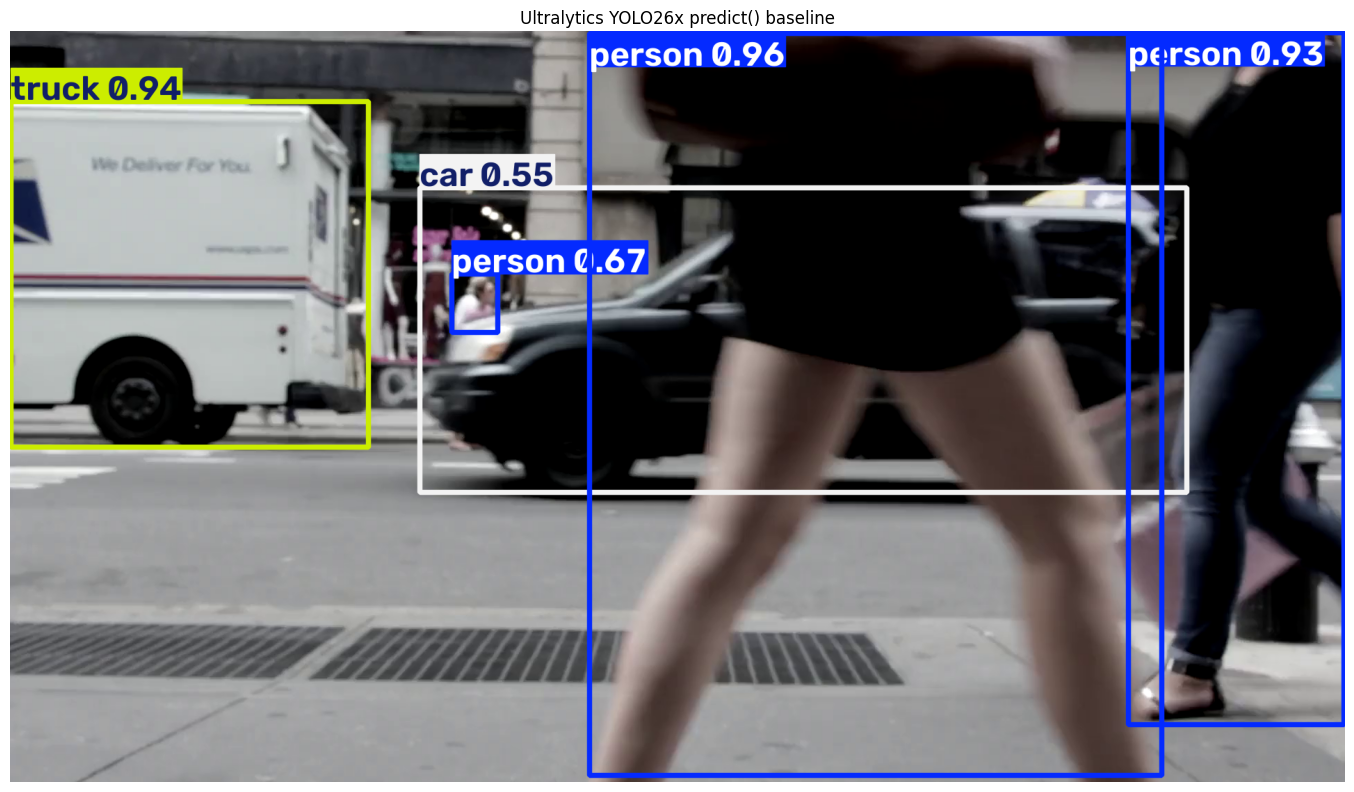

In [2]:
import cv2
from ultralytics import YOLO
from migraphx_cache import prepare_cache

capture = cv2.VideoCapture(str(env.SOURCE_VIDEO))
ok, first_frame = capture.read()
capture.release()
assert ok

cache_dir, cache_identity = prepare_cache(env.YOLO_ONNX, env.MIGRAPHX_CACHE, 0)
yolo = YOLO(str(env.YOLO_ONNX), task="detect")
result = yolo.predict(
    first_frame,
    device=0,
    half=True,
    imgsz=640,
    conf=0.5,
    iou=0.45,
    verbose=False,
)[0]
backend = yolo.predictor.model.backend
assert backend.provider == "MIGraphXExecutionProvider"
assert backend.use_io_binding and backend.migraphx_fp16
print({
    "boxes": len(result.boxes),
    "provider": backend.provider,
    "io_binding": backend.use_io_binding,
    "migraphx_fp16": backend.migraphx_fp16,
    "cache": str(cache_dir),
})
show_bgr(result.plot(), "Ultralytics YOLO26x predict() baseline")

## 3. Export the checkpoint to static ONNX

Set `RUN_EXPORT=1` to execute the real export. The default classroom path inspects the pre-exported official release asset so every attendee can move directly to deployment. Export uses a copy of the checkpoint and never overwrites the verified release ONNX.

In [3]:
import ast
import shutil
import onnx

RUN_EXPORT = os.environ.get("RUN_EXPORT", "0") == "1"
export_dir = env.OUTPUT / "export"
export_dir.mkdir(parents=True, exist_ok=True)
if RUN_EXPORT:
    checkpoint_copy = export_dir / env.YOLO_CHECKPOINT.name
    shutil.copy2(env.YOLO_CHECKPOINT, checkpoint_copy)
    exported_path = Path(
        YOLO(str(checkpoint_copy)).export(
            format="onnx",
            imgsz=640,
            batch=1,
            dynamic=False,
            simplify=False,
            device=0,
        )
    )
else:
    exported_path = env.YOLO_ONNX

onnx_model = onnx.load(str(exported_path), load_external_data=False)
input_shape = [item.dim_value for item in onnx_model.graph.input[0].type.tensor_type.shape.dim]
output_shape = [item.dim_value for item in onnx_model.graph.output[0].type.tensor_type.shape.dim]
metadata = {item.key: item.value for item in onnx_model.metadata_props}
print({
    "path": str(exported_path),
    "bytes": exported_path.stat().st_size,
    "input": input_shape,
    "output": output_shape,
    "end2end": metadata.get("end2end"),
    "task": metadata.get("task"),
})
assert input_shape == [1, 3, 640, 640]
assert output_shape == [1, 300, 6]

{'path': '/workspace/models/yolo26x.onnx', 'bytes': 223287479, 'input': [1, 3, 640, 640], 'output': [1, 300, 6], 'end2end': 'True', 'task': 'detect'}


## 4. Move from an image call to resident video buffers

The production adapter is initialized by `YOLO(...)` and keeps the Ultralytics predictor/backend alive. rocDecode returns a DLPack GPU tensor. OpenCV HIP reuses fixed padded, HWC, and BCHW buffers before the Ultralytics backend writes into a pre-bound GPU output.

In [4]:
from detector import UltralyticsYOLODetector
from preprocess import GPUPreprocessor
from video_io import RocDecodeReader

reader = RocDecodeReader(str(env.SOURCE_VIDEO), device_id=0)
processor = GPUPreprocessor((640, 640), device="cuda:0")
detector = UltralyticsYOLODetector(model_path=str(env.YOLO_ONNX), device_id=0)
try:
    ok, rgb_gpu = reader.read_gpu()
    assert ok and rgb_gpu.is_cuda
    blob_gpu, scale, pad_w, pad_h = processor.process(rgb_gpu)
    raw_gpu = detector.infer_gpu(blob_gpu)
    detections = detector._parse_gpu(
        raw_gpu, scale, pad_w, pad_h, tuple(rgb_gpu.shape)
    )
finally:
    reader.release()

print(json.dumps({
    "decoded": {"shape": list(rgb_gpu.shape), "device": str(rgb_gpu.device), "pointer": rgb_gpu.data_ptr()},
    "preprocess": {**processor.pointer_info(), "shape": list(blob_gpu.shape)},
    "inference": detector.provider_info(),
    "detections": detections,
}, indent=2))
assert blob_gpu.device.type == "cuda" and raw_gpu.device.type == "cuda"

[ERR]  {GetWidth}  Display width is 0.
[ERR]  {GetHeight}  Display height is 0.


[detector] Loading YOLO26x ONNX through Ultralytics...
[detector] MIGraphX cache identity: 735f1583e99dfeb733da
Loading /workspace/models/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


MIGraphX FP16 provider option is enabled; model input remains FP32.


2026-09-03 04:35:38.729357282 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


[detector] Ultralytics ONNX + MIGraphX EP (FP16, GPU I/O binding) ready; output=(1, 300, 6)


{
  "decoded": {
    "shape": [
      1080,
      1920,
      3
    ],
    "device": "cuda:0",
    "pointer": 136978733465600
  },
  "preprocess": {
    "hwc_pointer": 136980195180544,
    "blob_pointer": 136980200095744,
    "padded_pointer": 136979083689984,
    "float_hwc_pointer": 136979075301376,
    "shape": [
      1,
      3,
      640,
      640
    ]
  },
  "inference": {
    "owner": "ultralytics.YOLO",
    "ultralytics_format": "onnx",
    "provider": "MIGraphXExecutionProvider",
    "providers": [
      "MIGraphXExecutionProvider",
      "CPUExecutionProvider"
    ],
    "provider_options": {
      "migraphx_model_cache_dir": "\"/workspace/models/ort-migraphx-cache/735f1583e99dfeb733da\"",
      "device_id": "0",
      "migraphx_external_alloc": "0",
      "migraphx_fp8_enable": "0",
      "migraphx_int8_enable": "0",
      "migraphx_bf16_enable": "0",
      "migraphx_mem_limit": "18446744073709551615",
      "migraphx_int8_calibration_table_name": "",
      "migraphx_fp16

amdgpu: os_same_file_description couldn't determine if two DRM fds reference the same file description.
If they do, bad things may happen!


## 5. Check `predict()` to production parity

The two paths use different letterbox implementations, so byte-identical boxes are not expected. They must produce the same box count and classes, with class-matched IoU above 0.90.

In [5]:
from tests.test_predict_production_parity import validate as validate_parity

parity = validate_parity(env.YOLO_ONNX, env.SOURCE_VIDEO, minimum_iou=0.90)
print(json.dumps(parity, indent=2))

Loading /workspace/models/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


MIGraphX FP16 provider option is enabled; model input remains FP32.


2026-09-03 04:35:42.750271388 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


[detector] Loading YOLO26x ONNX through Ultralytics...
[detector] MIGraphX cache identity: 735f1583e99dfeb733da
Loading /workspace/models/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


MIGraphX FP16 provider option is enabled; model input remains FP32.


[detector] Ultralytics ONNX + MIGraphX EP (FP16, GPU I/O binding) ready; output=(1, 300, 6)
{
  "predict_boxes": 5,
  "production_boxes": 5,
  "classes": [
    0,
    0,
    0,
    2,
    7
  ],
  "minimum_class_matched_iou": 0.9275,
  "mean_class_matched_iou": 0.978,
  "minimum_required_iou": 0.9
}


2026-09-03 04:35:46.162999763 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


## 6. Benchmark the GPU-resident detection path

This benchmark excludes CPU overlay and encoded-video transport. It synchronizes each GPU stage and reports mean, P50, and P95 latency after warmup. It also asserts that all reusable buffer pointers stay unchanged.

A rocprof trace over 50 steady-state calls recorded zero memory-copy operations for both native MIGraphX and Ultralytics/ORT I/O Binding. The historical 50.8 FPS result is from a different date and ONNX, not a same-run backend comparison.

In [6]:
from tests.benchmark_gpu_stages import benchmark

RUN_BENCHMARK = os.environ.get("RUN_BENCHMARK", "0") == "1"
benchmark_path = env.OUTPUT / "benchmarks/gpu_stages.json"
if RUN_BENCHMARK or not benchmark_path.is_file():
    gpu_benchmark = benchmark(env.SOURCE_VIDEO, frames=120, warmup=10)
    benchmark_path.parent.mkdir(parents=True, exist_ok=True)
    benchmark_path.write_text(json.dumps(gpu_benchmark, indent=2) + "\n")
else:
    gpu_benchmark = json.loads(benchmark_path.read_text())
print(json.dumps({
    "stages": gpu_benchmark["stages"],
    "gpu_path_mean_ms": gpu_benchmark["gpu_path_mean_ms"],
    "gpu_path_fps": gpu_benchmark["gpu_path_fps"],
    "stable_pointers": gpu_benchmark["stable_pointers"],
}, indent=2))

{
  "stages": {
    "decode": {
      "mean_ms": 2.656,
      "p50_ms": 0.94,
      "p95_ms": 5.412
    },
    "preprocess": {
      "mean_ms": 0.317,
      "p50_ms": 0.314,
      "p95_ms": 0.377
    },
    "inference": {
      "mean_ms": 14.214,
      "p50_ms": 14.427,
      "p95_ms": 16.1
    },
    "gpu_nms": {
      "mean_ms": 2.606,
      "p50_ms": 2.253,
      "p95_ms": 2.517
    }
  },
  "gpu_path_mean_ms": 19.793,
  "gpu_path_fps": 50.5,
  "stable_pointers": {
    "hwc_pointer": 123503676227584,
    "blob_pointer": 123503681142784,
    "padded_pointer": 123508183007232,
    "float_hwc_pointer": 123508174618624,
    "output_pointer": 123502403256320
  }
}


## 7. Connect inference to the production video loop

The command below forces hardware decode and `vaapi-direct`. A bounded worker queue holds each resident RGB tensor, waits on a producer event from the inference stream, then performs RGB-to-NV12 and box/text/status overlay on a dedicated HIP stream inside a separate FFmpeg-owned DRM PRIME VA-API encoder surface. `VAAPI_DEVICE` selects the render node assigned by Radeon Cloud.

In [7]:
from scripts import pipeline_workflow as workflow

print(" ".join(workflow.pipeline_command(max_frames=120)))
print("VA-API device:", os.environ.get("VAAPI_DEVICE", "/dev/dri/renderD128"))

/opt/venv/bin/python3 /workspace/src/pipeline.py --input /workspace/data/sidewalk.mp4 --output /workspace/output/pipeline/01_yolo_base.mp4 --no-vlm --video-decode rocdecode --video-encode vaapi --gpu-direct-encode on --max-frames 120
VA-API device: /dev/dri/renderD135


## 8. Extend detections with Qwen3-VL scene understanding

YOLO answers *what and where* for every frame. Qwen3-VL samples short temporal segments and adds *what is happening* as a timeline and subtitle track. The VLM runs asynchronously from the detector and its latency is reported separately.

In [8]:
from scripts import pipeline_workflow as workflow

if workflow.TIMELINE.is_file():
    timeline = json.loads(workflow.TIMELINE.read_text())
    for segment in timeline["segments"]:
        print(f'{segment["start"]:4.1f}-{segment["end"]:4.1f}s  {segment["caption"]}')
else:
    print("Run the end-to-end notebook to generate the Qwen3-VL timeline.")

 0.0- 4.0s  Pedestrians cross street as cars pass by in busy urban setting.
 4.0- 8.0s  Pedestrian crosses street as vehicles pass by in urban setting.
 8.0-12.0s  Pedestrians and cyclist cross street near food cart and delivery truck.
12.0-15.7s  Pedestrians cross street as delivery truck passes by urban sidewalk.


## 9. Copy audit

**Main YOLO/no-VLM pass: no full-frame D2H**

- rocDecode surface -> DLPack tensor
- fixed OpenCV HIP preprocess buffers
- fixed Ultralytics/ORT GPU input and output bindings
- OpenCV GPU confidence filtering and NMS
- resident RGB tensor held by a bounded queue
- HIP RGB-to-NV12 plus box/text/status overlay
- DRM PRIME VAAPI encoder surface -> `h264_vaapi`

**Explicit host boundaries**

- compact surviving boxes/classes/scores copied after GPU NMS
- notebook visualization downloads only the selected display frame
- Qwen3-VL baseline uses JPEG/HTTP transport
- subtitle rendering retains CPU text layout and the host-frame VA-API writer
- `--gpu-direct-encode off` retains the full-frame D2H/raw-pipe fallback

The direct bridge writes into a separate FFmpeg-owned encoder surface; it is not rocDecode-surface passthrough. The main vision pass has zero full-frame D2H, while the Qwen3-VL and subtitle pass still has documented host boundaries.


A whole-loop rocprof CSV/JSON export was attempted, but ROCm 7.2.1 failed in its result writer after the application completed (`ring_buffer mmap errno 22`), leaving unusable output. It is not counted as trace evidence. The successful 50-call `MEASURE_YOLO` inference trace remains a separate, narrower proof.